In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.sandbox.regression.predstd import wls_prediction_std

In [2]:
nsample = 50
groups = np.zeros(nsample, int)
groups[20:40] = 1
groups[40:] = 2
dummy = pd.get_dummies(groups).values
x = np.linspace(0,20,nsample)
X = np.column_stack((x, dummy[:,1:]))
X = sm.add_constant(X, prepend=False)
beta = [1.,3,-3,10]
y_true = np.dot(X, beta)
e = np.random.normal(size=nsample)
y = y_true + e

In [10]:
dummy

array([[ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [False,  True, False],
       [Fa

In [5]:
res = sm.OLS(y, X).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     622.3
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           3.16e-37
Time:                        23:01:06   Log-Likelihood:                -66.269
No. Observations:                  50   AIC:                             140.5
Df Residuals:                      46   BIC:                             148.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.9307      0.062     15.037      0.000       0.806       1.055
x2             3.5267      0.588      6.001      0.000       2.344       4.710
x3            -2.2390      0.958     -2.338      0.024      -4.167      -0.311
const         10.2616      0.320     32.025      0.000       9.617      10.907
==============================================================================
Omnibus:                        2.454   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.293   Jarque-Bera (JB):                1.413
Skew:                          -0.034   Prob(JB):                        0.493
Kurtosis:                       2.179   Cond. No.                         96.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
def plot_compare(res):
    prstd, iv_1, iv_u = wls_prediction_std(res)
    fig, ax = plt.subplots(figsize=(10,6))

    ax.plot(x, y, 'o', label='data')
    ax.plot(x, y_true, 'b--', label="True")
    ax.plot(x, res.fittedvalues, 'r--', label="OLS")
    ax.plot(x, iv_u, 'g--', label="Error")
    ax.plot(x, iv_1, 'g--')
    ax.legend(loc="best")

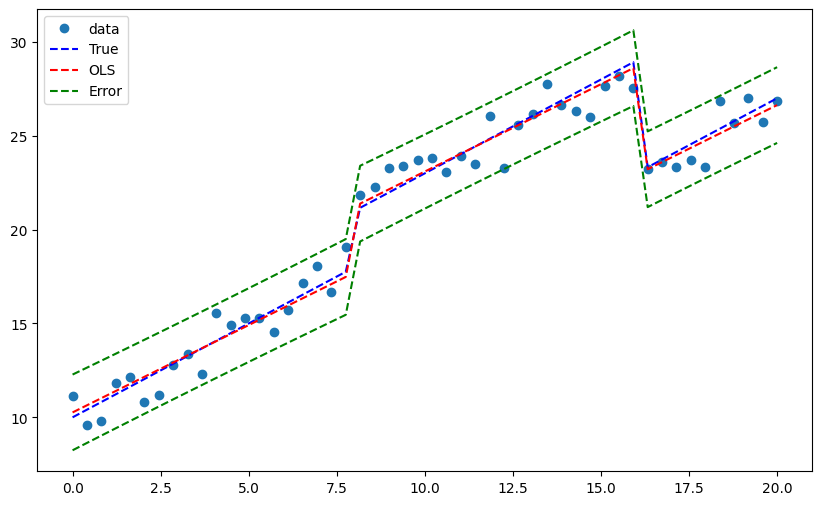

In [9]:
plot_compare(res)